In [1]:
import sys
print(sys.executable)

c:\Users\KIIT0001\anaconda3\envs\obesity_env\python.exe


In [4]:
!pip install pandas numpy seaborn matplotlib scikit-learn

  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 2.4 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/11.3 MB 2.5 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/11.3 MB 2.5 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.3 MB 2.5 MB/s eta 0:00:04
   --------- ------------------------------ 2.6/11.3 MB 2.4 MB/s eta 0:00:04
   ----------- ---------------------------- 3.1/11.3 MB 2.5 MB/s eta 0:00:04
   ------------- -------------------------- 3.9/11.3 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 4.5/11.3 MB 2.7 MB/s eta 0:00:03
   ----------------- ---------------------- 5.0/11.3 MB 2.7 MB/s eta 0:00:03
   -------------------- ------------------- 5.8/11.3 MB 2.8 MB/s eta 0:00:03
   ----------------------- ---------------- 6.6/11.3 MB 2.8 MB/s eta 0:00:02
   ---------

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


LOADING THE DATASET

In [6]:
ob_dataset= pd.read_csv('ObesityDataSet[1].csv')

In [7]:
ob_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [8]:
dataset=pd.DataFrame(ob_dataset)

In [9]:
dataset

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


CHECKING THE MISSING VALUES

In [10]:
dataset.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

STATS OF DATA

In [11]:
dataset.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [12]:
dataset.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


EXPLORATORY DATA ANALYSIS

CORELLATION

In [16]:
dataset.corr(numeric_only=True)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Age,1.000000,-0.025958,0.202560,0.016291,-0.043944,-0.045304,-0.144938,-0.296931
Height,-0.025958,1.000000,0.463136,-0.038121,0.243672,0.213376,0.294709,0.051912
Weight,0.202560,0.463136,1.000000,0.216125,0.107469,0.200575,-0.051436,-0.071561
FCVC,0.016291,-0.038121,0.216125,1.000000,0.042216,0.068461,0.019939,-0.101135
NCP,-0.043944,0.243672,0.107469,0.042216,1.000000,0.057088,0.129504,0.036326
CH2O,-0.045304,0.213376,0.200575,0.068461,0.057088,1.000000,0.167236,0.011965
FAF,-0.144938,0.294709,-0.051436,0.019939,0.129504,0.167236,1.000000,0.058562
TUE,-0.296931,0.051912,-0.071561,-0.101135,0.036326,0.011965,0.058562,1.000000


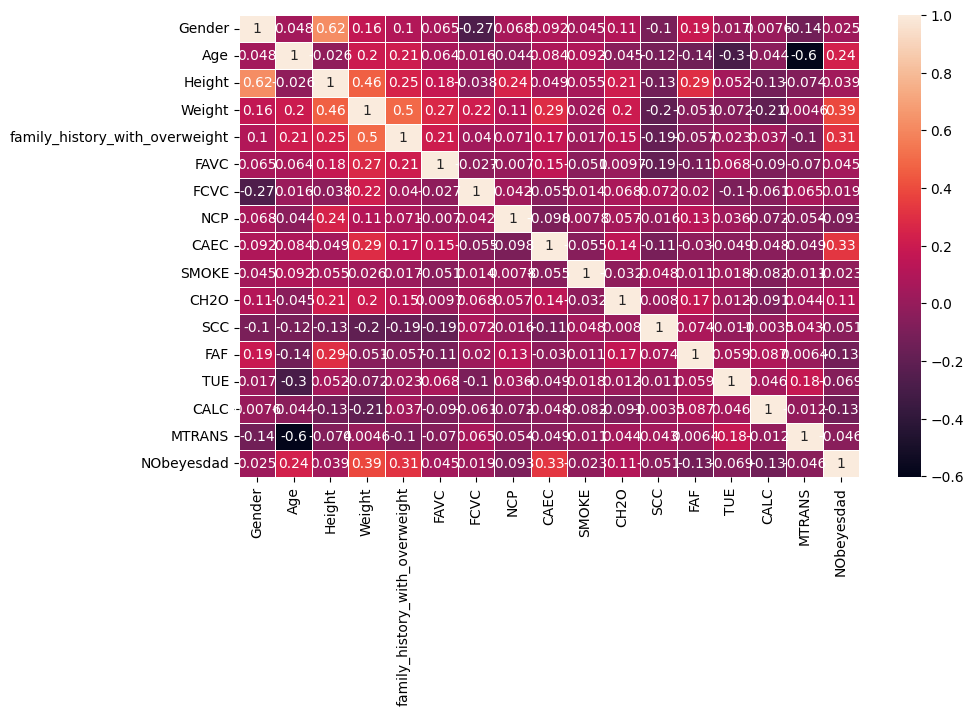

In [39]:
num_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10,6))
sns.heatmap(dataset[num_cols].corr(), annot=True, linewidths=0.5)
plt.show()

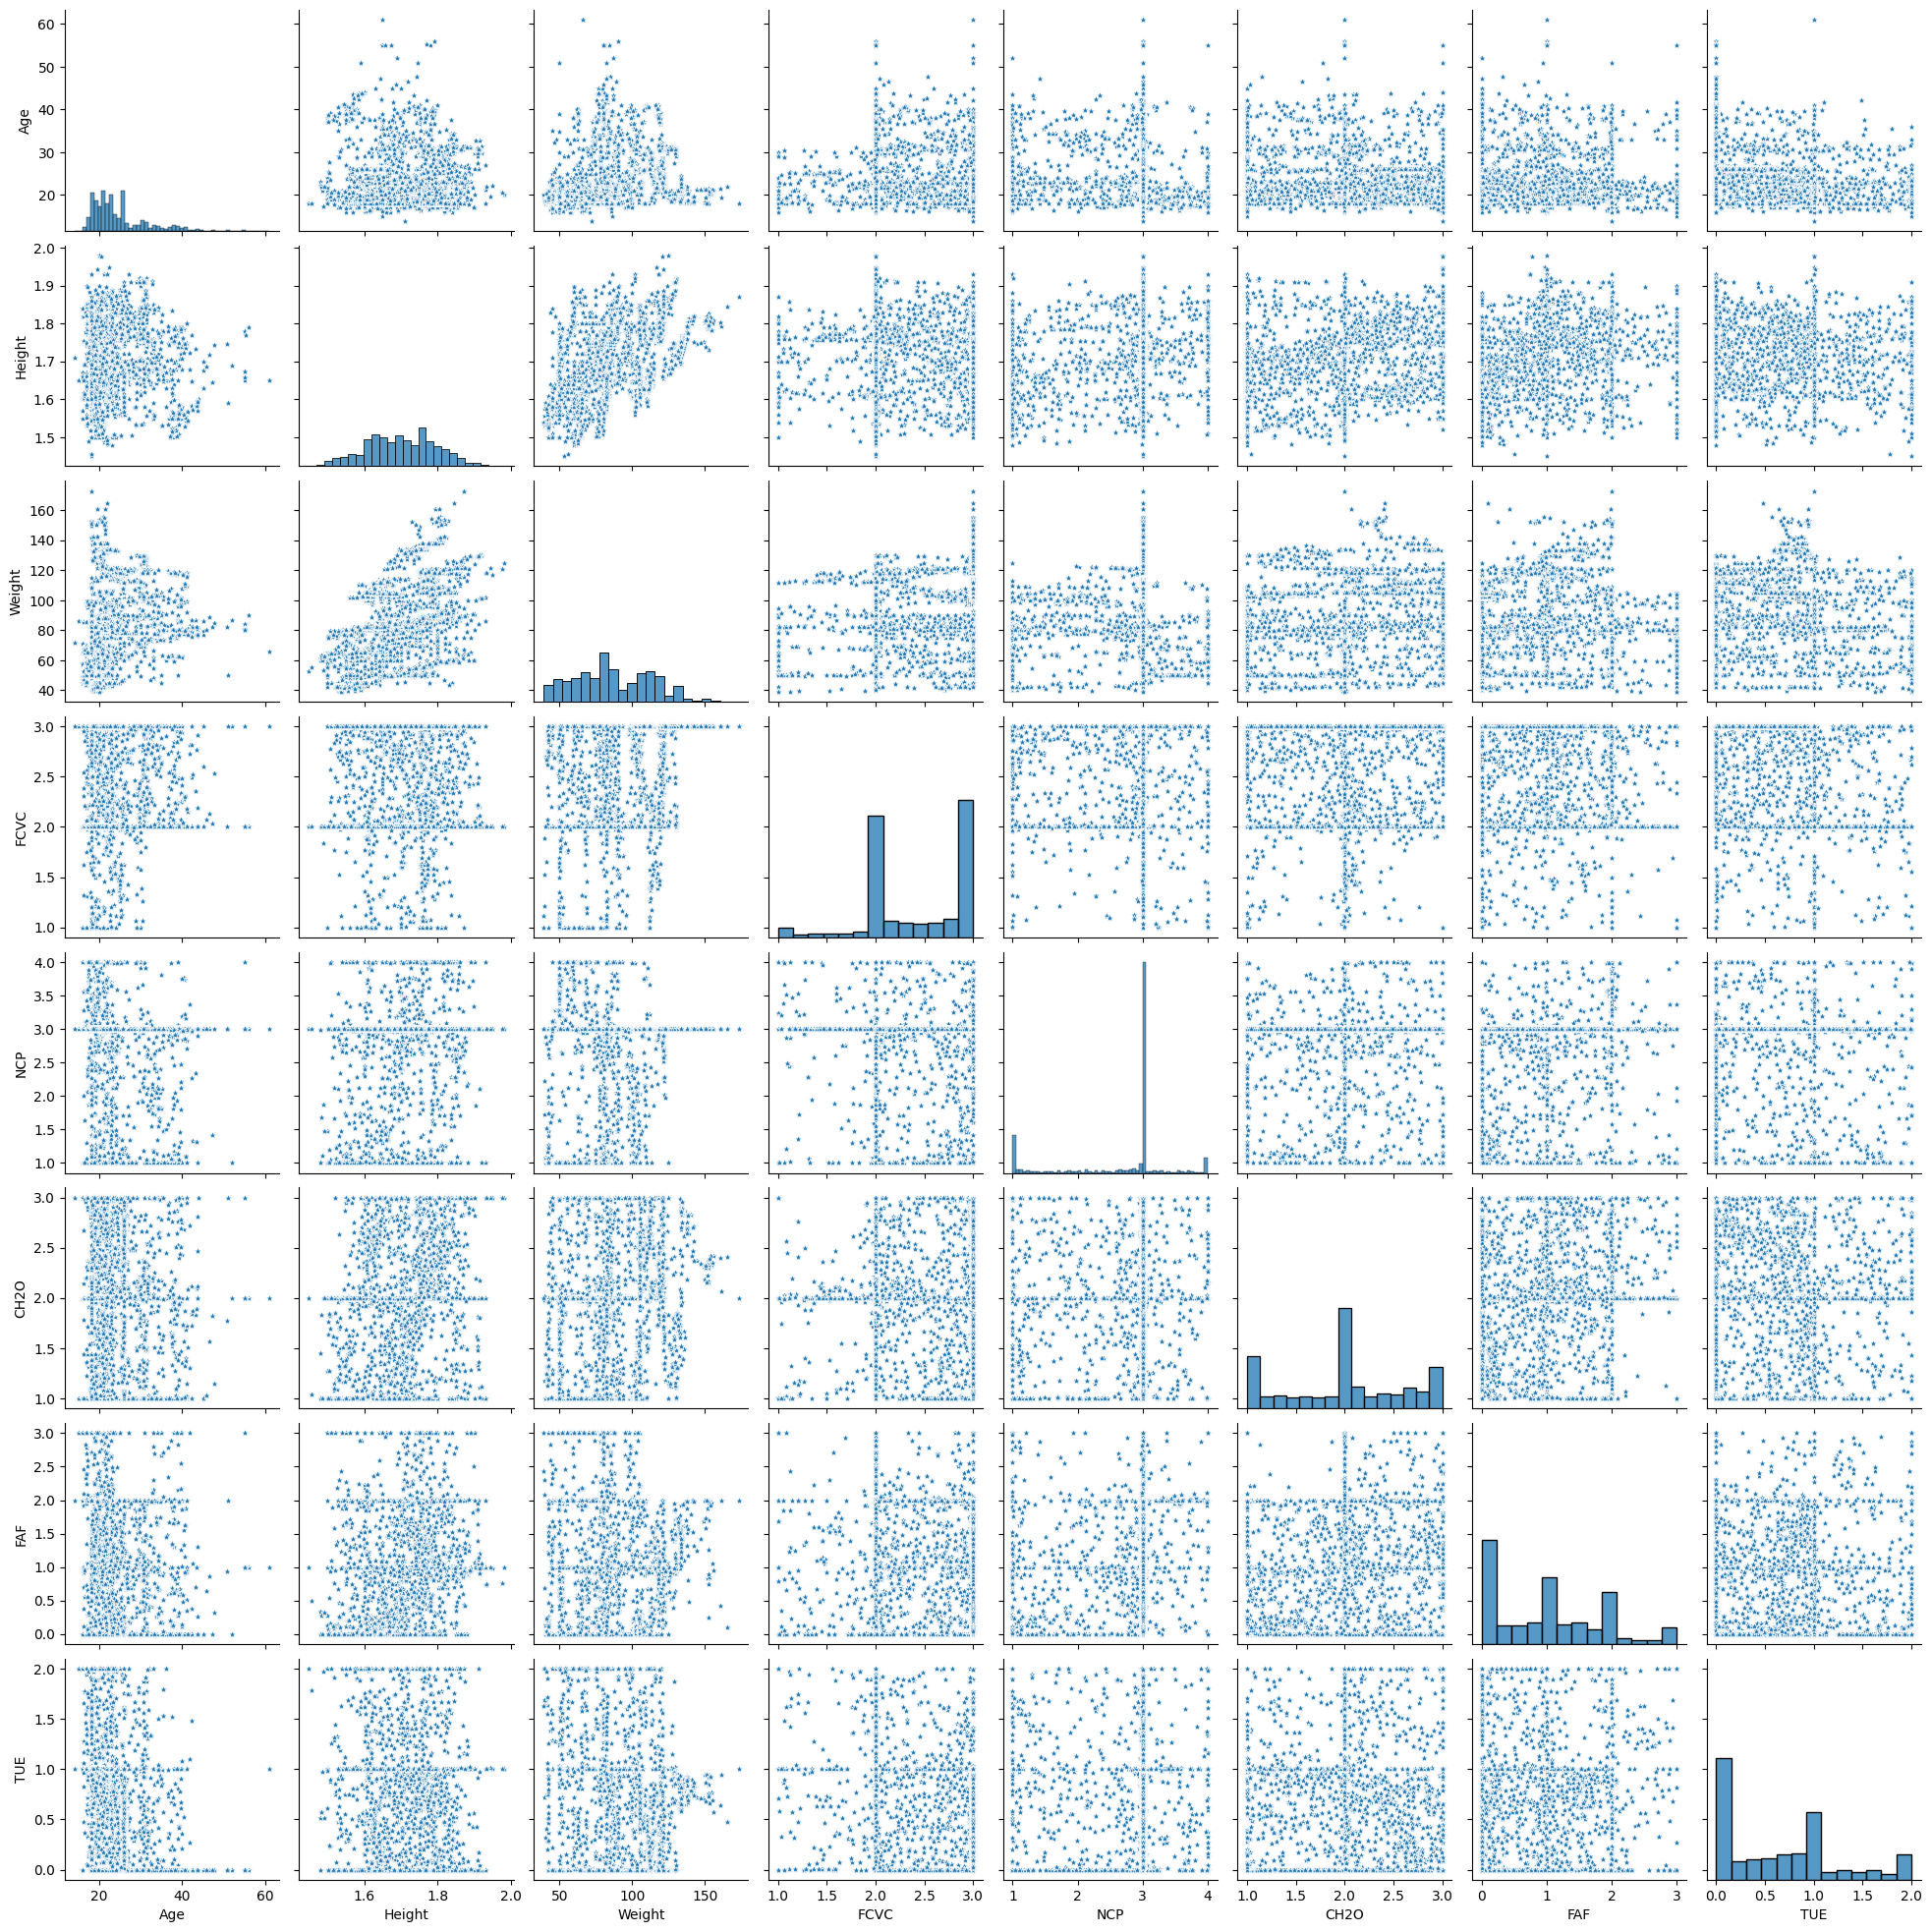

In [18]:
sns.pairplot(dataset,markers='*')

Text(0.5, 1.0, 'Obesity vs Transportation')

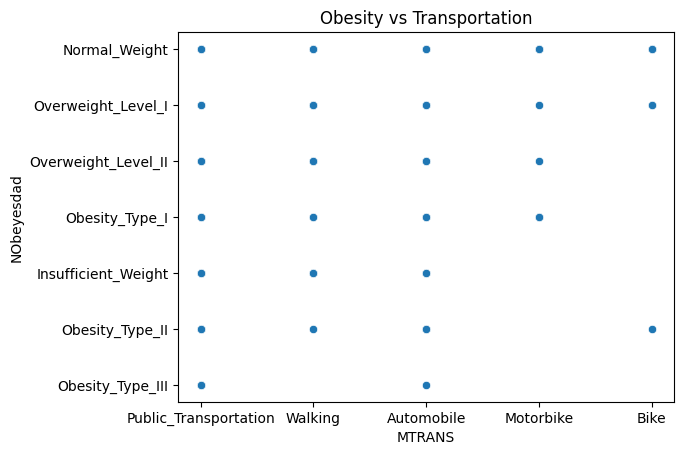

In [19]:
sns.scatterplot(x='MTRANS', y='NObeyesdad',markers='*', data=dataset)
plt.title('Obesity vs Transportation')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Normal_Weight'),
  Text(1, 0, 'Overweight_Level_I'),
  Text(2, 0, 'Overweight_Level_II'),
  Text(3, 0, 'Obesity_Type_I'),
  Text(4, 0, 'Insufficient_Weight'),
  Text(5, 0, 'Obesity_Type_II'),
  Text(6, 0, 'Obesity_Type_III')])

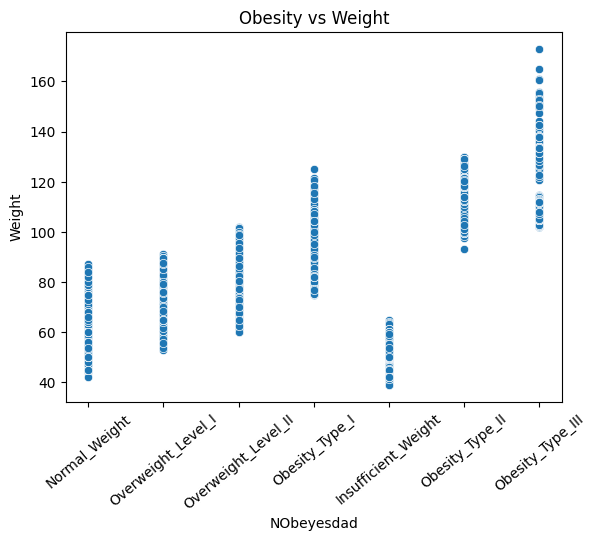

In [20]:
sns.scatterplot(x='NObeyesdad', y='Weight',markers='+', data=dataset)
plt.title('Obesity vs Weight')
plt.xticks(rotation = 40)


Text(0.5, 1.0, 'Obesity vs Height')

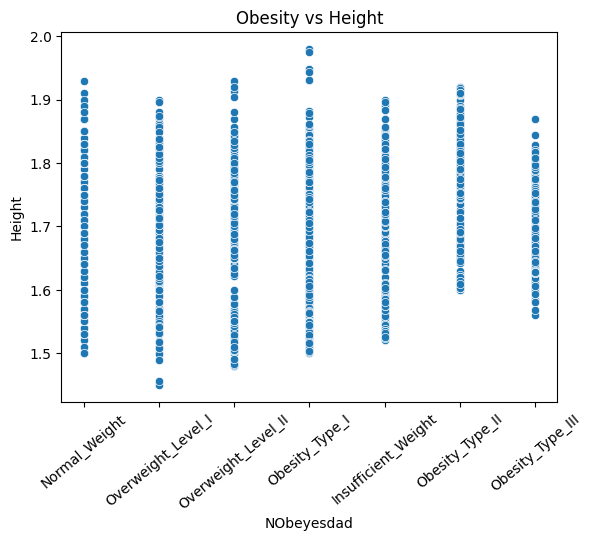

In [21]:
sns.scatterplot(x='NObeyesdad', y='Height', data=dataset,markers='.')
plt.xticks(rotation = 40)
plt.title('Obesity vs Height')

Text(0.5, 1.0, 'Obesity vs Age')

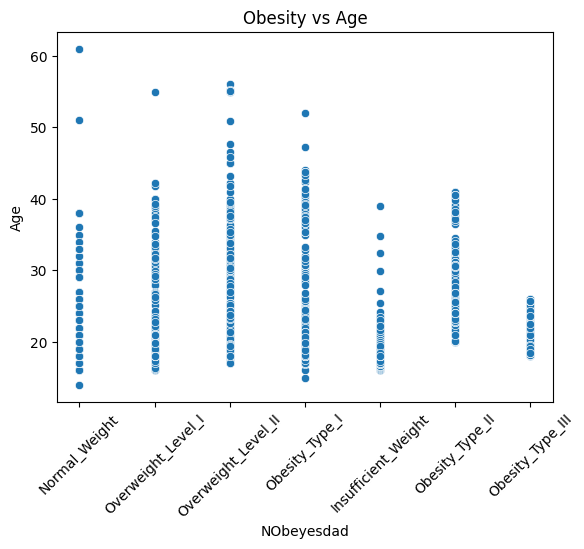

In [22]:
sns.scatterplot(x='NObeyesdad', y='Age', data=dataset,markers='.')
plt.xticks(rotation = 45)
plt.title('Obesity vs Age')

Text(0.5, 1.0, 'Obesity vs CAEC')

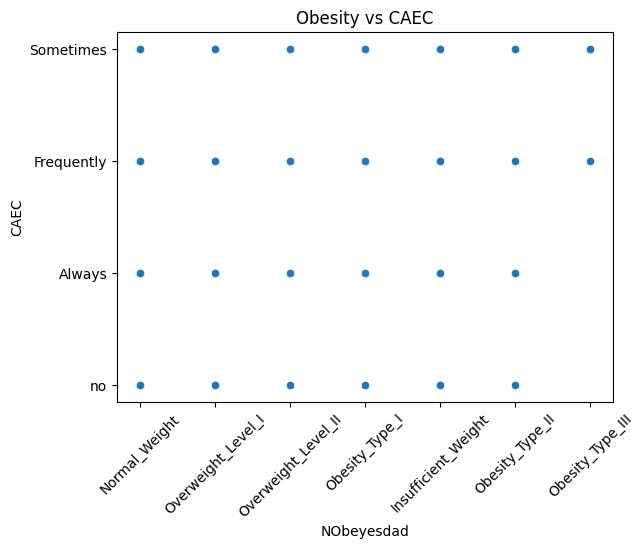

In [23]:
sns.scatterplot(x='NObeyesdad', y='CAEC', data=dataset,markers='*')
plt.xticks(rotation = 45)
plt.title('Obesity vs CAEC')

Text(0.5, 1.0, 'Obesity vs CALC')

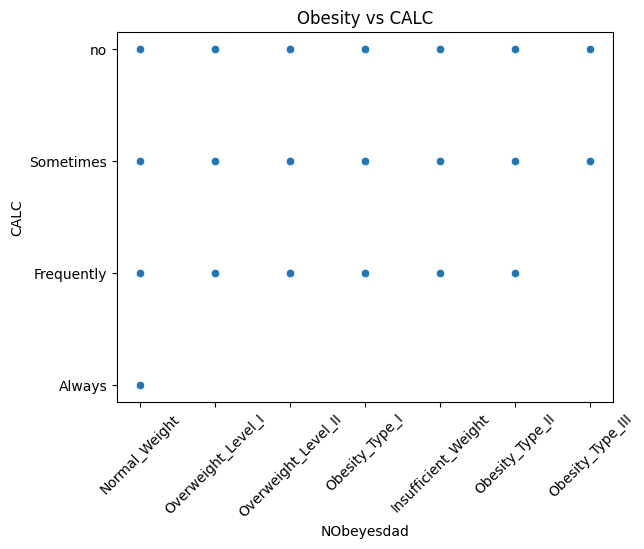

In [24]:
sns.scatterplot(x='NObeyesdad', y='CALC', data=dataset)
plt.xticks(rotation = 45)
plt.title('Obesity vs CALC')

In [25]:
lb=LabelEncoder()

In [26]:
dataset['Gender'] = lb.fit_transform(dataset['Gender'])
dataset['family_history_with_overweight'] = lb.fit_transform(dataset['family_history_with_overweight'])
dataset['FAVC'] = lb.fit_transform(dataset['FAVC'])
dataset['CAEC'] = lb.fit_transform(dataset['CAEC'])
dataset['SMOKE'] = lb.fit_transform(dataset['SMOKE'])
dataset['SCC'] = lb.fit_transform(dataset['SCC'])
dataset['CALC'] = lb.fit_transform(dataset['CALC'])
dataset['MTRANS'] = lb.fit_transform(dataset['MTRANS'])
dataset['NObeyesdad'] = lb.fit_transform(dataset['NObeyesdad'])

In [27]:
dataset.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22.0,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6


In [28]:
dataset['NObeyesdad'].value_counts()

NObeyesdad
2    351
4    324
3    297
5    290
6    290
1    287
0    272
Name: count, dtype: int64

In [29]:
labels=ob_dataset['NObeyesdad'].unique()

In [30]:
labels


array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

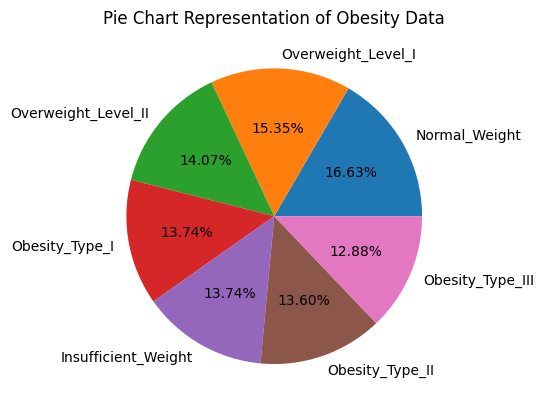

In [31]:
plt.pie(dataset['NObeyesdad'].value_counts(),labels=labels,autopct='%0.02f%%')
plt.title('Pie Chart Representation of Obesity Data')
plt.show()
#Data is balanced.

In [32]:
#Split dataset into independent and dependent features

In [33]:
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [34]:
X


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,2,0,2.000000,0,0.000000,1.000000,3,3
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,2,1,3.000000,1,3.000000,0.000000,2,3
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,2,0,2.000000,0,2.000000,1.000000,1,3
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,2,0,2.000000,0,2.000000,0.000000,1,4
4,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,2,0,2.000000,0,0.000000,0.000000,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,2,0,1.728139,0,1.676269,0.906247,2,3
2107,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,2,0,2.005130,0,1.341390,0.599270,2,3
2108,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,2,0,2.054193,0,1.414209,0.646288,2,3
2109,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,2,0,2.852339,0,1.139107,0.586035,2,3


In [35]:
y

0       1
1       1
2       1
3       5
4       6
       ..
2106    4
2107    4
2108    4
2109    4
2110    4
Name: NObeyesdad, Length: 2111, dtype: int64

In [36]:
lb.fit(y)
y=lb.transform(y)
classes=lb.classes_

In [37]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Logistic regression

In [38]:
from sklearn.linear_model import LogisticRegression
regression=LogisticRegression()

In [40]:
from sklearn.model_selection import GridSearchCV
parameter={'penalty':['l1','l2','elasticnet'],'C':[1,5,10,15,30],'max_iter':[100,300,500,700,900]}
           

In [41]:
regressor_gscv=GridSearchCV(regression,param_grid=parameter,scoring= 'accuracy',cv=5)

In [42]:
regressor_gscv.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [1, 5, ...], 'max_iter': [100, 300, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [43]:
print(regressor_gscv.best_params_)

{'C': 15, 'max_iter': 900, 'penalty': 'l2'}


In [44]:
print(regressor_gscv.best_score_)

0.8168290540270735


In [45]:
y_pred= regressor_gscv.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score,classification_report

In [47]:
score=accuracy_score(y_pred,y_test)
print(score)

0.8314393939393939


In [48]:
print(classification_report(y_pred,y_test))


              precision    recall  f1-score   support

           0       0.96      0.86      0.90        76
           1       0.60      0.82      0.70        57
           2       0.81      0.86      0.84        88
           3       0.97      0.86      0.91        85
           4       1.00      0.98      0.99        81
           5       0.79      0.72      0.75        78
           6       0.68      0.68      0.68        63

    accuracy                           0.83       528
   macro avg       0.83      0.83      0.82       528
weighted avg       0.85      0.83      0.84       528



In [49]:
from sklearn.metrics import confusion_matrix
conf_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print(conf_matrix)

confusion matrix:
[[65  3  0  0  0  0  0]
 [11 47  0  0  0 15  5]
 [ 0  0 76 10  1  0  7]
 [ 0  0  2 73  0  0  0]
 [ 0  0  0  0 79  0  0]
 [ 0  7  0  0  0 56  8]
 [ 0  0 10  2  1  7 43]]


<Axes: >

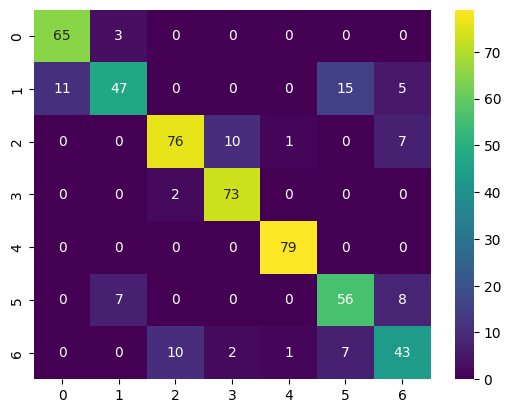

In [50]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='viridis')

Decision tree

In [51]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
treemodel=DecisionTreeClassifier(max_depth=10)

In [53]:
treemodel.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.648704594017094, 0.9545454545454546, 'x[3] <= 99.568\ngini = 0.856\nsamples = 1583\nvalue = [204.0, 209.0, 257.0, 222.0, 245.0, 219.0, 227.0]'),
 Text(0.37219551282051283, 0.8636363636363636, 'x[3] <= 61.514\ngini = 0.801\nsamples = 1041\nvalue = [204, 209, 181, 5, 0, 219, 223]'),
 Text(0.5104500534188035, 0.9090909090909092, 'True  '),
 Text(0.1639957264957265, 0.7727272727272727, 'x[2] <= 1.66\ngini = 0.489\nsamples = 320\nvalue = [202, 107, 0, 0, 0, 9, 2]'),
 Text(0.060897435897435896, 0.6818181818181818, 'x[3] <= 46.828\ngini = 0.546\nsamples = 171\nvalue = [66, 94, 0, 0, 0, 9, 2]'),
 Text(0.017094017094017096, 0.5909090909090909, 'x[3] <= 44.959\ngini = 0.138\nsamples = 67\nvalue = [62, 5, 0, 0, 0, 0, 0]'),
 Text(0.008547008547008548, 0.5, 'gini = 0.0\nsamples = 54\nvalue = [54, 0, 0, 0, 0, 0, 0]'),
 Text(0.02564102564102564, 0.5, 'x[2] <= 1.58\ngini = 0.473\nsamples = 13\nvalue = [8, 5, 0, 0, 0, 0, 0]'),
 Text(0.017094017094017096, 0.4090909090909091, 'gini = 0.0\nsamples

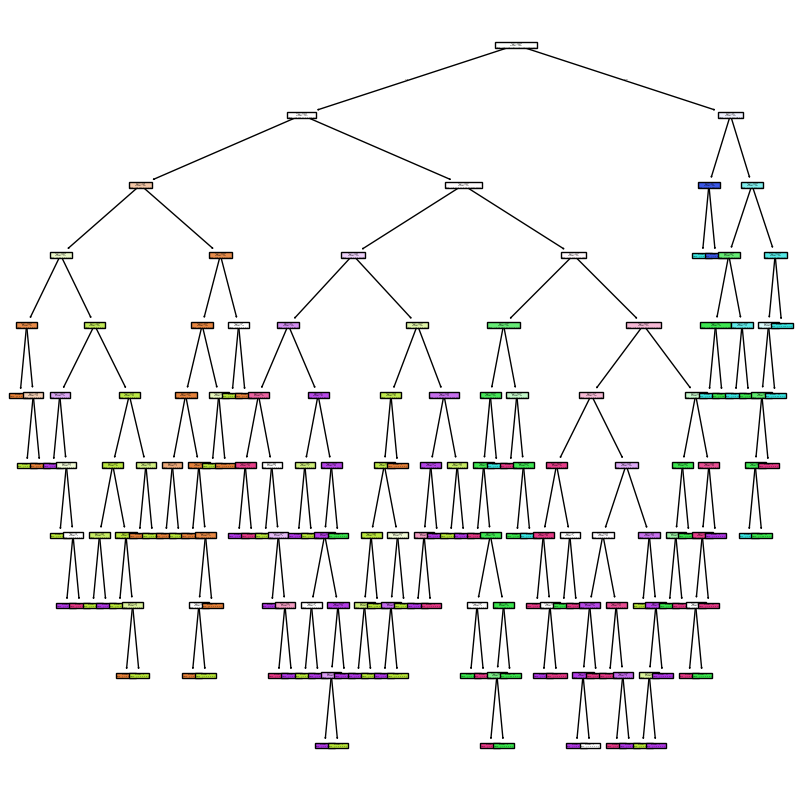

In [54]:
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(treemodel,filled=True)

In [55]:
#prediction
y_pred=treemodel.predict(X_test)

In [56]:
score=accuracy_score(y_pred,y_test)
print(score)

0.9053030303030303


In [57]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91        72
           1       0.82      0.82      0.82        78
           2       0.90      0.94      0.92        90
           3       0.96      0.95      0.95        76
           4       0.99      1.00      0.99        78
           5       0.86      0.81      0.84        75
           6       0.86      0.92      0.89        59

    accuracy                           0.91       528
   macro avg       0.90      0.90      0.90       528
weighted avg       0.91      0.91      0.91       528



In [58]:
conf_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print(conf_matrix)

confusion matrix:
[[64  4  0  0  0  0  0]
 [ 8 64  0  0  0  6  0]
 [ 0  1 85  4  0  0  4]
 [ 0  0  3 72  0  0  0]
 [ 0  0  1  0 78  0  0]
 [ 0  9  0  0  0 61  1]
 [ 0  0  1  0  0  8 54]]


<Axes: >

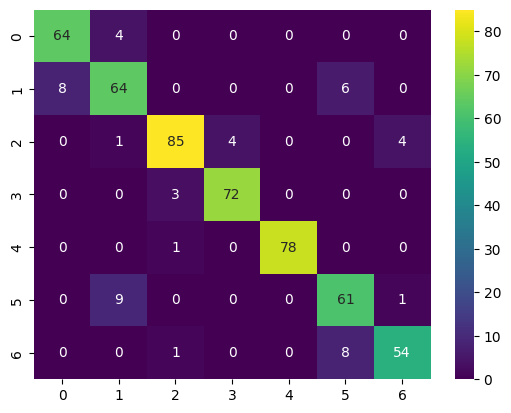

In [59]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='viridis')

Random Forest Classifier

In [60]:
from sklearn.ensemble import RandomForestClassifier 

In [61]:
rf_model=RandomForestClassifier(random_state=42,max_depth=10,n_estimators=100)

In [62]:
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
#prediction
y_pred=rf_model.predict(X_test)

In [64]:
score=accuracy_score(y_test,y_pred)
print(score)

0.9299242424242424


In [65]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        68
           1       0.80      0.90      0.85        78
           2       0.98      0.91      0.95        94
           3       0.96      0.99      0.97        75
           4       1.00      0.99      0.99        79
           5       0.88      0.86      0.87        71
           6       0.92      0.94      0.93        63

    accuracy                           0.93       528
   macro avg       0.93      0.93      0.93       528
weighted avg       0.93      0.93      0.93       528



In [66]:
conf_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print(conf_matrix)

confusion matrix:
[[63  5  0  0  0  0  0]
 [ 2 70  0  0  0  5  1]
 [ 0  2 86  3  0  0  3]
 [ 0  0  1 74  0  0  0]
 [ 0  0  1  0 78  0  0]
 [ 0  9  0  0  0 61  1]
 [ 0  1  0  0  0  3 59]]


<Axes: >

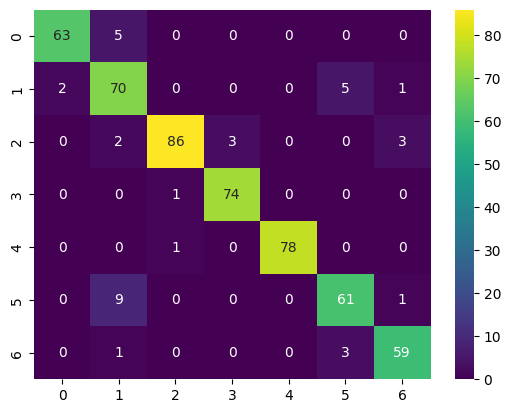

In [67]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='viridis')

Support Vector Machines(SVMs)

In [68]:
from sklearn import svm

In [69]:
svm_classifier=svm.SVC(kernel='linear',C=50)

In [70]:
svm_classifier.fit(X_train,y_train)

,C,50
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
y_pred=svm_classifier.predict(X_test)

In [72]:
score=accuracy_score(y_test,y_pred)
print(score)

0.9696969696969697


In [73]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        68
           1       0.99      0.94      0.96        78
           2       0.97      0.98      0.97        94
           3       0.96      1.00      0.98        75
           4       1.00      0.99      0.99        79
           5       0.96      0.94      0.95        71
           6       0.95      0.94      0.94        63

    accuracy                           0.97       528
   macro avg       0.97      0.97      0.97       528
weighted avg       0.97      0.97      0.97       528



In [74]:
conf_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print(conf_matrix)

confusion matrix:
[[68  0  0  0  0  0  0]
 [ 3 73  0  0  0  2  0]
 [ 0  0 92  2  0  0  0]
 [ 0  0  0 75  0  0  0]
 [ 0  0  0  1 78  0  0]
 [ 0  1  0  0  0 67  3]
 [ 0  0  3  0  0  1 59]]


<Axes: >

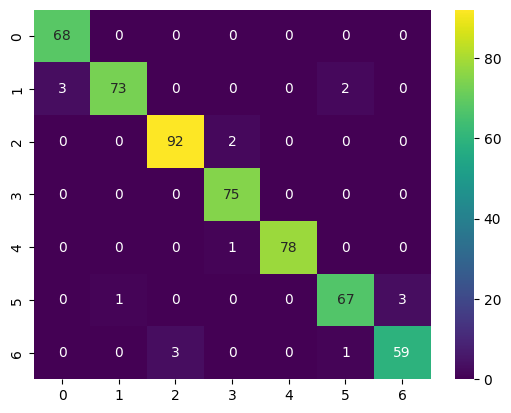

In [75]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='viridis')

In [76]:
#Checking for overfitting and underfitting

In [77]:
train_acc=accuracy_score(y_train,svm_classifier.predict(X_train))
test_acc= accuracy_score(y_test,svm_classifier.predict(X_test))

In [78]:
print(f"training accuracy={train_acc:.4f}, test accuracy={test_acc:.4f}")

training accuracy=0.9728, test accuracy=0.9697


Catboost

In [84]:
import sys
!{sys.executable} -m pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 3.4 MB/s eta 0:00:30
    --------------------------------------- 1.3/100.2 MB 3.9 MB/s eta 0:00:26
    --------------------------------------- 2.1/100.2 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 3.1/100.2 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.9/100.2 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 4.7/100.2 MB 4.2 MB/s eta 0:00:23
   -- ------------------------------------- 6.0/100.2 MB 4.3 MB/s eta 0:00:22
   -- ------------------------------------- 6.8/100.2 MB 4.4 MB/s eta 0:00:22
   --- ------------------------------------ 7.9/100.2 MB 4.5 MB/s eta 0:00:21
   --- ------------------------------------ 9.2/100.2 MB 4.6 MB/s eta 0:00:20
   ---- ----------------------------------- 10.2/100.2 MB 4.6 MB/s eta 0:00:20
   ---- ----------------------------------- 11.5/100.2 MB 4.7 MB/s eta

In [85]:
from catboost import CatBoostClassifier

In [86]:
catboost_model= CatBoostClassifier(iterations=900,learning_rate=0.2, depth=5)

In [87]:
catboost_model.fit(X_train, y_train,eval_set=(X_test,y_test),verbose=False)

CatBoostClassifier(depth=5, iterations=900, learning_rate=0.2)

In [88]:
#predictions
y_pred= catboost_model.predict(X_test)

In [89]:
score=accuracy_score(y_test,y_pred)
print(score)

0.9621212121212122


In [90]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        68
           1       0.92      0.88      0.90        78
           2       0.98      0.98      0.98        94
           3       0.97      0.99      0.98        75
           4       1.00      0.99      0.99        79
           5       0.90      0.92      0.91        71
           6       0.98      1.00      0.99        63

    accuracy                           0.96       528
   macro avg       0.96      0.96      0.96       528
weighted avg       0.96      0.96      0.96       528



In [91]:
conf_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print(conf_matrix)

confusion matrix:
[[67  1  0  0  0  0  0]
 [ 2 69  0  0  0  7  0]
 [ 0  0 92  2  0  0  0]
 [ 0  0  1 74  0  0  0]
 [ 0  0  1  0 78  0  0]
 [ 0  5  0  0  0 65  1]
 [ 0  0  0  0  0  0 63]]


<Axes: >

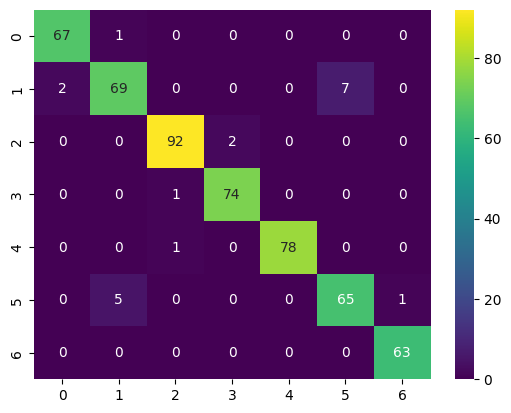

In [92]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='viridis')

Naive Bayes

In [93]:
from sklearn.naive_bayes import GaussianNB

In [94]:
model_nb= GaussianNB()

In [95]:
model_nb.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [96]:
y_pred=model_nb.predict(X_test)

In [97]:
score=accuracy_score(y_test,y_pred)
print(score)

0.6212121212121212


In [98]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.85      0.75        68
           1       0.57      0.36      0.44        78
           2       0.41      0.62      0.49        94
           3       0.69      0.91      0.78        75
           4       1.00      0.99      0.99        79
           5       0.49      0.31      0.38        71
           6       0.57      0.25      0.35        63

    accuracy                           0.62       528
   macro avg       0.63      0.61      0.60       528
weighted avg       0.62      0.62      0.60       528



In [99]:
conf_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print(conf_matrix)

confusion matrix:
[[58  3  5  0  0  2  0]
 [27 28  6  0  0 12  5]
 [ 0  1 58 26  0  6  3]
 [ 0  0  6 68  0  0  1]
 [ 0  0  1  0 78  0  0]
 [ 2 10 34  0  0 22  3]
 [ 0  7 32  5  0  3 16]]


<Axes: >

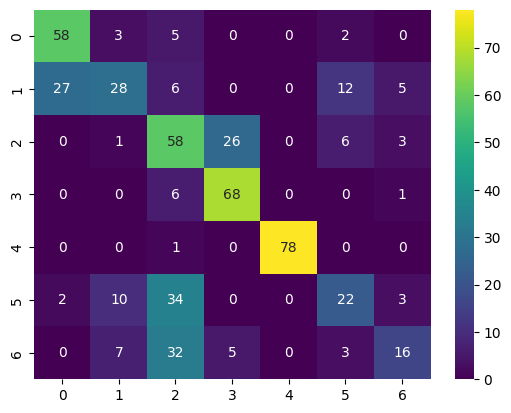

In [100]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='viridis')

AdaBoost

In [101]:
from sklearn.ensemble import AdaBoostClassifier

In [103]:
ada_boost= AdaBoostClassifier(n_estimators=50, random_state=42,estimator=treemodel,learning_rate=1)

In [104]:
ada_boost.fit(X_train,y_train)

,estimator,DecisionTreeC...(max_depth=10)
,n_estimators,50
,learning_rate,1
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [105]:
y_pred= ada_boost.predict(X_test)

In [106]:
score=accuracy_score(y_test,y_pred)
print(score)

0.9640151515151515


In [107]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        68
           1       0.92      0.91      0.92        78
           2       0.99      0.97      0.98        94
           3       0.95      0.99      0.97        75
           4       1.00      0.99      0.99        79
           5       0.93      0.93      0.93        71
           6       0.98      1.00      0.99        63

    accuracy                           0.96       528
   macro avg       0.96      0.96      0.96       528
weighted avg       0.96      0.96      0.96       528



In [108]:
conf_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print(conf_matrix)

confusion matrix:
[[66  2  0  0  0  0  0]
 [ 2 71  0  0  0  5  0]
 [ 0  0 91  3  0  0  0]
 [ 0  0  1 74  0  0  0]
 [ 0  0  0  1 78  0  0]
 [ 0  4  0  0  0 66  1]
 [ 0  0  0  0  0  0 63]]


<Axes: >

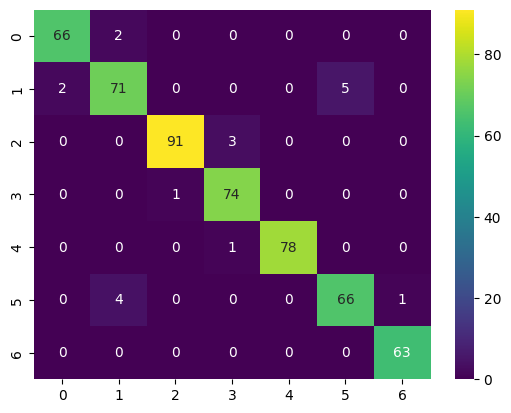

In [109]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='viridis')

XGBoost

In [111]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 3.0 MB/s eta 0:00:35
    --------------------------------------- 1.3/101.7 MB 2.5 MB/s eta 0:00:41
    --------------------------------------- 1.6/101.7 MB 2.2 MB/s eta 0:00:46
    --------------------------------------- 1.8/101.7 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 2.1/101.7 MB 1.8 MB/s eta 0:00:55
    --------------------------------------- 2.4/101.7 MB 1.7 MB/s eta 0:00:59
   - -------------------------------------- 2.6/101.7 MB 1.6 MB/s eta 0:01:02
   - -------------------------------------- 2.9/101.7 MB 1.6 MB/s eta 0:01:04
   - -------------------------------------- 3.1/101.7 MB 1.5 MB/s eta 0:01:05
   - -------------------------------------- 3.7/101.7 MB 1.6 MB/s eta 0:01:03
   - -------------------------------------- 3.9/101.7 MB 1.6 MB/s eta 0:01:03


In [112]:
import xgboost as xgb

In [113]:
model_xgb=xgb.XGBClassifier(num_class=7,learning_rate=0.1,max_depth=5,gamma=0.1,reg_alpha=0.1,reg_lambda=1.0)


In [114]:
model_xgb.fit(X_train,y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [115]:
y_pred=model_xgb.predict(X_test)

In [116]:
score=accuracy_score(y_test,y_pred)
print(score)

0.9583333333333334


In [117]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        68
           1       0.93      0.85      0.89        78
           2       0.99      0.98      0.98        94
           3       0.97      0.99      0.98        75
           4       1.00      0.99      0.99        79
           5       0.89      0.93      0.91        71
           6       0.98      1.00      0.99        63

    accuracy                           0.96       528
   macro avg       0.96      0.96      0.96       528
weighted avg       0.96      0.96      0.96       528



In [118]:
conf_matrix= confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print(conf_matrix)

confusion matrix:
[[67  1  0  0  0  0  0]
 [ 5 66  0  0  0  7  0]
 [ 0  0 92  1  0  1  0]
 [ 0  0  1 74  0  0  0]
 [ 0  0  0  1 78  0  0]
 [ 0  4  0  0  0 66  1]
 [ 0  0  0  0  0  0 63]]


<Axes: >

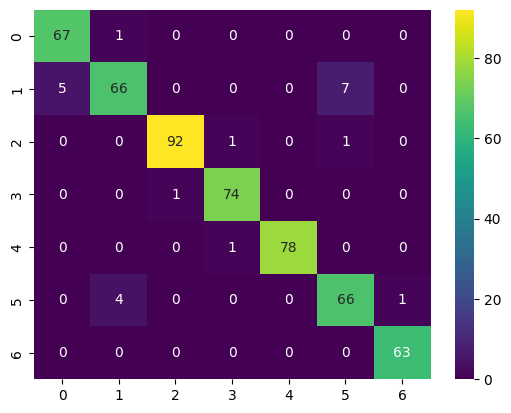

In [119]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='viridis')

ROC CURVE AND AREA UNDER CURVE

In [120]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier


In [ ]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler=MinMaxScaler()
X_train_norm=min_max_scaler.fit_transform(X_train)
X_test_norm=min_max_scaler.fit_transform(X_test)


In [122]:
X_train_norm[0,0]

np.float64(0.0)

In [123]:
X_train.iloc[0,0]

np.int64(0)

In [124]:
RF= OneVsRestClassifier(svm.SVC(kernel='linear',C=50,probability=True))
RF.fit(X_train_norm,y_train)
y_pred=RF.predict(X_test_norm)
pred_prob=RF.predict_proba(X_test_norm)

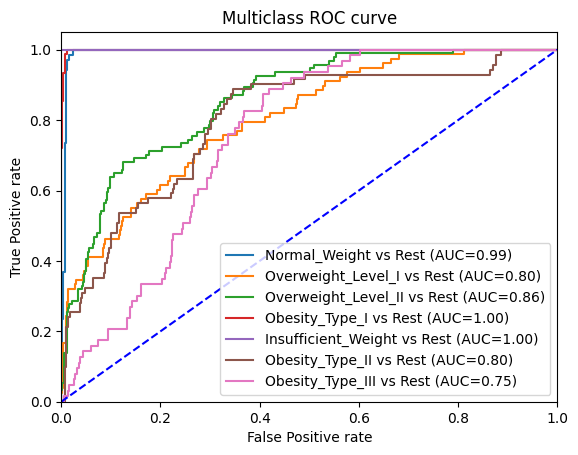

In [125]:
y_test_binarized=label_binarize(y_test,classes=np.unique(y_test))

fpr = {}
tpr = {}
thresh={}
roc_auc=dict()
n_class=classes.shape[0]

for i in range(n_class):
    fpr[i], tpr[i], thresh[i]= roc_curve(y_test_binarized[:, i], pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
for i in range(n_class):
         plt.plot(fpr[i], tpr[i], linestyle='-',
         label='%s vs Rest (AUC=%0.2f)'%(labels[i],roc_auc[i]))

plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()

In [126]:
#Graphical Representation of Metrices all Models

In [127]:
model_names = ['LR', 'DT', 'RF', 'SVM', 'CB', 'NB', 'AB', 'XGB']
accuracy_values = [0.8200, 0.9242, 0.9299, 0.9697, 0.9621, 0.6212, 0.9659, 0.9583]
precision_values =[0.8171, 0.9257, 0.9314, 0.9700, 0.9671, 0.6128, 0.9528, 0.9614]
recall_values = [0.8128, 0.9242, 0.9300, 0.9700, 0.9642, 0.6285, 0.9657, 0.9557]
f1_values=[0.8128, 0.9214, 0.9300, 0.9214, 0.9614, 0.5971, 0.9657, 0.9571]


In [128]:
metrics_dict = {}
for i, model_name in enumerate(model_names):
    metrics_dict[model_name] = {
        'Accuracy': accuracy_values[i],
        'Precision': precision_values[i],
        'Recall': recall_values[i],
        'F1_Score': f1_values[i]
    }

In [129]:
model_names = list(metrics_dict.keys())
metric_labels = list(metrics_dict[model_names[0]].keys())

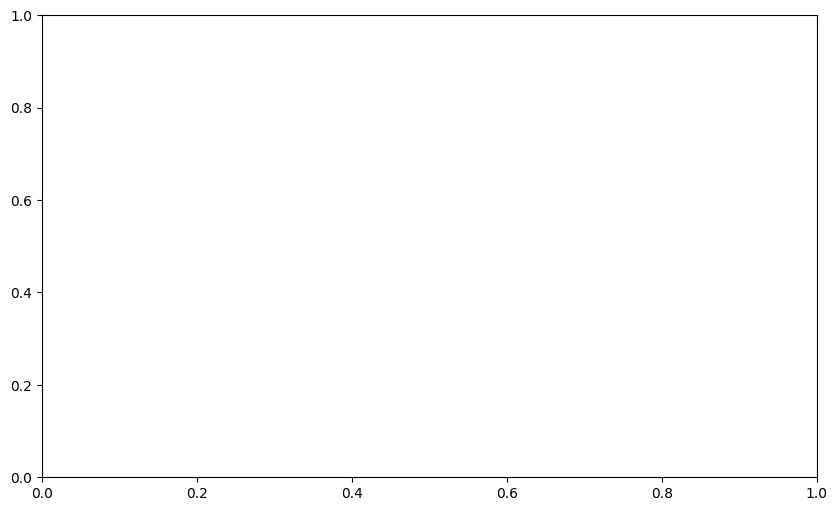

In [130]:
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
bar_positions = np.arange(len(model_names))

In [131]:
for i, metric_label in enumerate(metric_labels):
    metric_values = [metrics_dict[model_name][metric_label] for model_name in model_names]
    ax.bar(bar_positions + (i * bar_width), metric_values, width=bar_width, label=metric_label)

In [132]:
ax.set_xlabel('Models')
ax.set_ylabel('Metric Scores')
ax.set_title('Comparison of ML Models on Metrics')
ax.set_xticks(bar_positions + ((len(metric_labels) - 1) / 2) * bar_width)
ax.set_xticklabels(model_names)
ax.legend()

In [133]:
plt.show()

In [134]:
import pickle

pickle.dump(svm_classifier, open("obesity_model.pkl", "wb"))

In [136]:
import numpy
import sklearn
print(numpy.__version__)
print(sklearn.__version__)

2.2.6
1.7.2


THE END

Thank you for reading and your support! I hope you have enjoyed this humble work!

Your opinion is always greatly appreciated.